# import libraries 

In [53]:
import numpy as np
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer 
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder , StandardScaler
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error , mean_absolute_error ,r2_score

# loading the dataset 

In [3]:
df = pd.read_csv('Downloads/linear regression/student-por.csv')

In [4]:
df.head(20)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13
5,GP,M,16,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,6,12,12,13
6,GP,M,16,U,LE3,T,2,2,other,other,...,4,4,4,1,1,3,0,13,12,13
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,2,10,13,13
8,GP,M,15,U,LE3,A,3,2,services,other,...,4,2,2,1,1,1,0,15,16,17
9,GP,M,15,U,GT3,T,3,4,other,other,...,5,5,1,1,1,5,0,12,12,13


# UNDERSTANDING the dataset 

In [6]:
df.shape # 649 rows and 33 columns 

(649, 33)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 non-null    str  
 19  nursery     649 non-null    str  
 20  higher      649 non-null    str  
 21  inte

In [8]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [10]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='str')

# DATA cleaning 

In [11]:
df.isnull()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
645,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
646,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
647,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [12]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [14]:
df.isnull().sum().sum()

np.int64(0)

# check duplicate values 

In [15]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
644    False
645    False
646    False
647    False
648    False
Length: 649, dtype: bool

In [16]:
df.duplicated().sum()

np.int64(0)

# data types 

In [18]:
df.dtypes

school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object

# checking for unusal values or outliers 

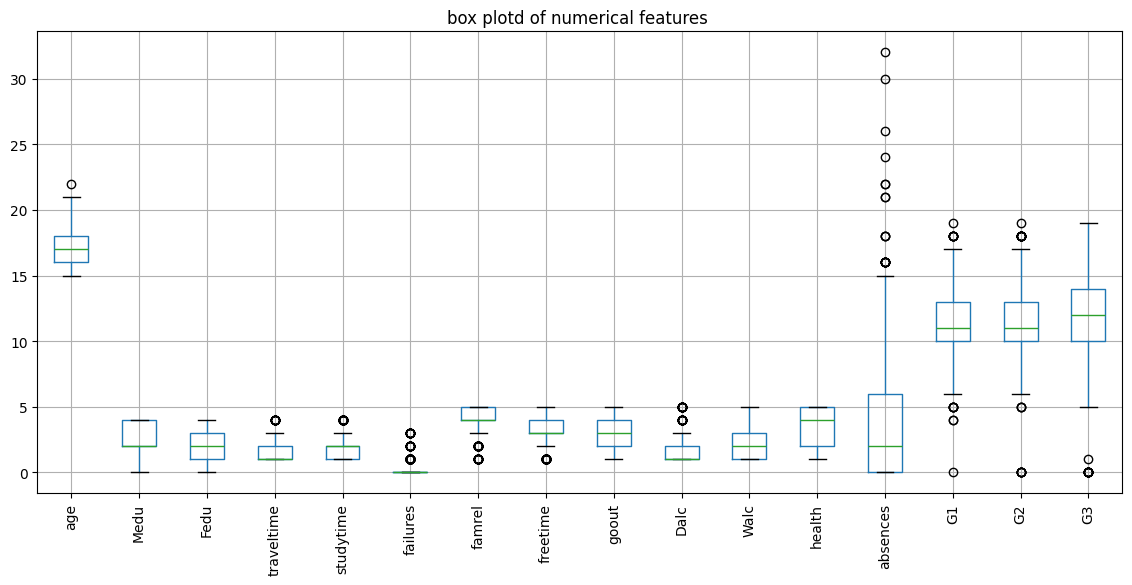

In [20]:
df.select_dtypes(include=np.number).boxplot(figsize=(14,6),rot=90) 
plt.title("box plotd of numerical features " ) 
plt.show()

# The boxplot shows the presence of several potential outliers across the numerical features, particularly in absences, G1, and G2. These observations are unusually distant from the central distribution. Since they may represent genuine student behavior rather than data-entry errors, they should be investigated before deciding whether to remove or retain them.

# exploratory data analysis


# distribution of final scores 

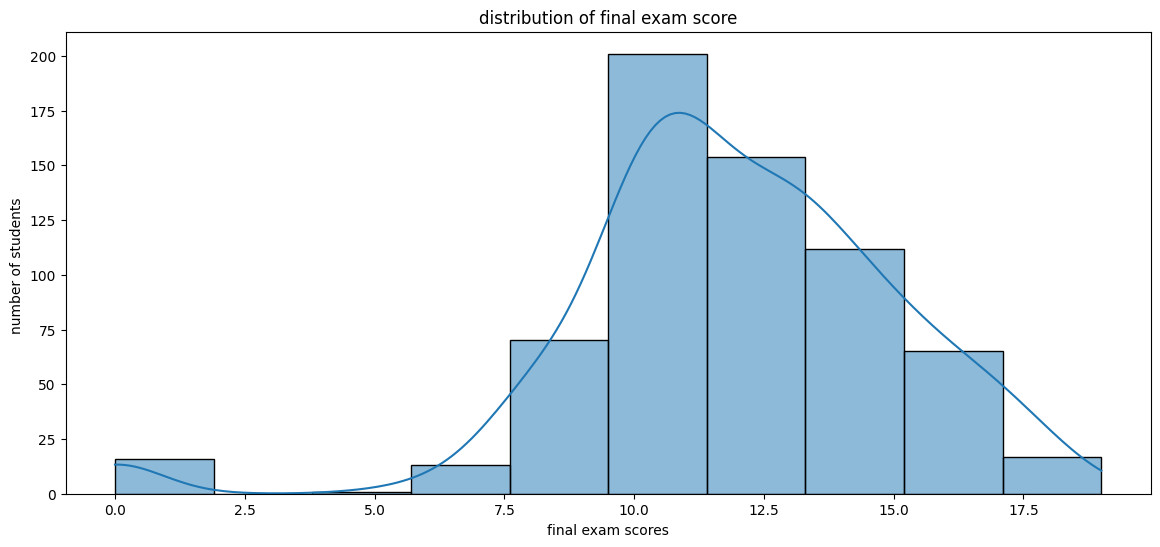

In [24]:
plt.figure(figsize=(14,6)) 
sns.histplot(df['G3'] , bins= 10 , kde=True)
plt.title("distribution of final exam score")
plt.ylabel('number of students ') 
plt.xlabel("final exam scores")
plt.show()

# summary statistics 

In [25]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


# relationship between study time and final score 

<Figure size 800x500 with 0 Axes>

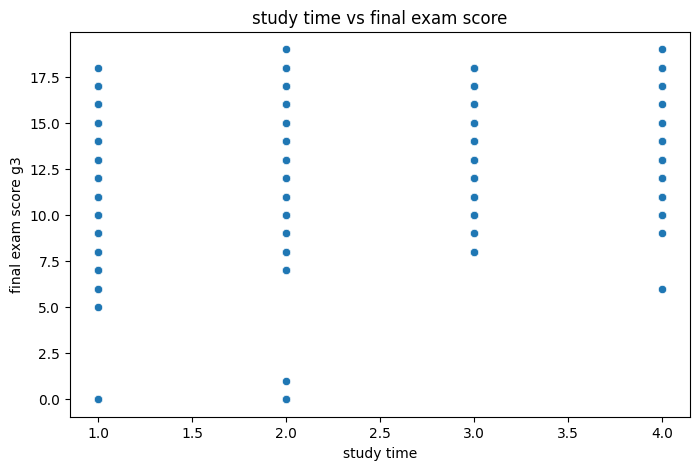

In [30]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df , x= 'studytime' , y='G3') 
plt.title("study time vs final exam score")
plt.xlabel("study time")
plt.ylabel("final exam score g3")
plt.show()

# So there is some indication that higher study time may be associated with better scores, particularly because the study-time = 3 and 4 groups don't show the extremely low scores as often.However, the relationship is not very strong or perfectly linear because there is a lot of variation within each study-time category.

# RELATIONSHIP between g1 vs g3 and g2 vs g3

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

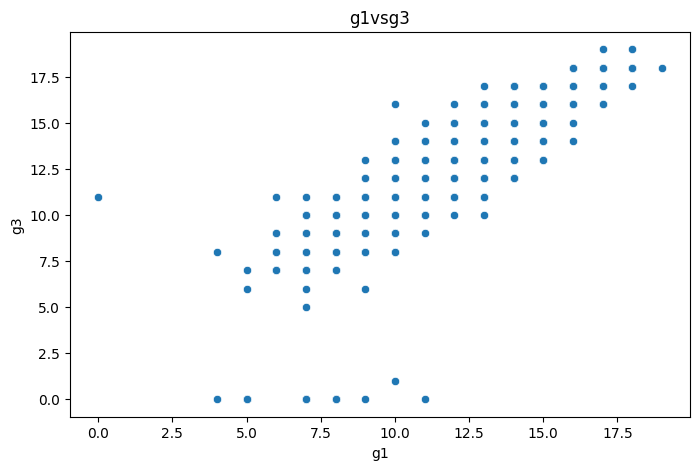

In [33]:
plt.figure(figsize=(8,5))
sns.scatterplot(data= df , x='G1',y='G3')
plt.title("g1vsg3")
plt.xlabel('g1')
plt.ylabel('g3')
plt.show()

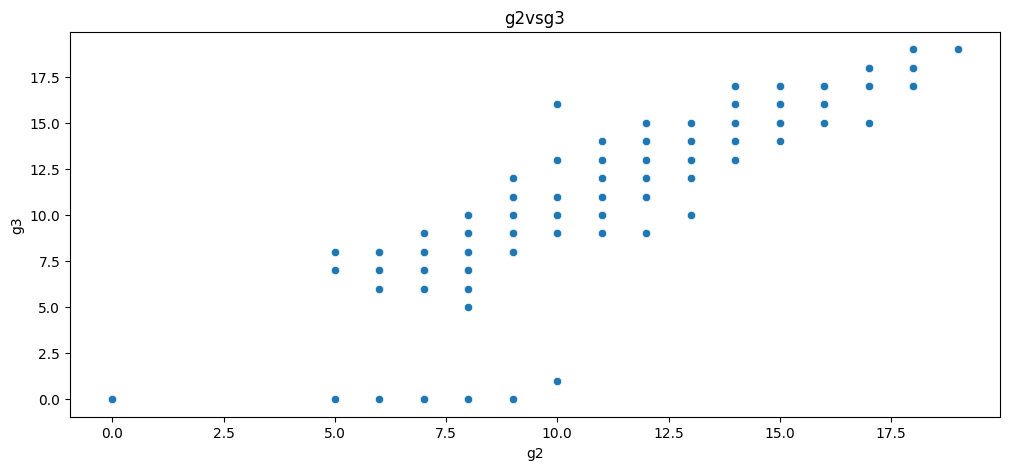

In [34]:
plt.figure(figsize=(12,5))
sns.scatterplot(data=df, x='G2', y='G3') 
plt.title('g2vsg3')
plt.xlabel('g2')
plt.ylabel('g3')
plt.show()

# The scatter plot shows a strong positive linear relationship between G2 and G3. Students with higher G2 scores generally tend to achieve higher G3 scores. The points are mostly concentrated around an upward-sloping pattern, suggesting that G2 may be an important predictor of the final exam score. A few observations with very low G3 values deviate from the general trend and may require further investigation.

# correlation matrix

In [37]:
numeric_df = df.select_dtypes(include=np.number)
numeric_df

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,18,4,4,2,2,0,4,3,4,1,1,3,4,0,11,11
1,17,1,1,1,2,0,5,3,3,1,1,3,2,9,11,11
2,15,1,1,1,2,0,4,3,2,2,3,3,6,12,13,12
3,15,4,2,1,3,0,3,2,2,1,1,5,0,14,14,14
4,16,3,3,1,2,0,4,3,2,1,2,5,0,11,13,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,19,2,3,1,3,1,5,4,2,1,2,5,4,10,11,10
645,18,3,1,1,2,0,4,3,4,1,1,1,4,15,15,16
646,18,1,1,2,2,0,1,1,1,1,1,5,6,11,12,9
647,17,3,1,2,1,0,2,4,5,3,4,2,6,10,10,10


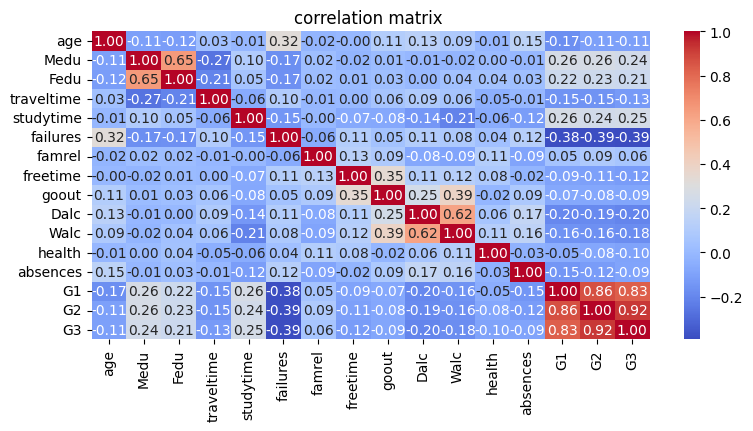

In [39]:
correlation_matrix = numeric_df.corr()
plt.figure(figsize=(9,4))
sns.heatmap(correlation_matrix, annot=True , cmap='coolwarm' , fmt='.2f')
plt.title( 'correlation matrix ')
plt.show()

# The strongest positive relationships with final exam score are G2 and G1. Students who perform well in earlier exams generally perform well in the final exam. Previous failures have a moderate negative relationship with final performance. Most other variables have relatively weak relationships with G3.

# defining x and y 

In [40]:
x = df.drop('G3' , axis=1) 
y= df['G3']

# train test split

In [74]:
x_train , x_test , y_train , y_test = train_test_split(x,y, test_size=0.20 , random_state=42)

In [71]:
print("x shape:", x.shape)
print("y shape:", y.shape)

print("\nX columns:")
print(x.columns.tolist())

print("\nTarget y:")
print(y.head())
print(y.dtype)

x shape: (649, 32)
y shape: (649,)

X columns:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']

Target y:
0    11
1    11
2    12
3    14
4    13
Name: G3, dtype: int64
int64


In [72]:
print(y.unique())

[11 12 14 13 17 15  7 10 16  9  8 18  6  0  1  5 19]


In [73]:
print("Target column:", y.name)

Target column: G3


# identify numerical and catehorical features 

In [69]:
numeric_features = x.select_dtypes(include=['int64','float64']).columns
categorical_features = x.select_dtypes(include=['str']).columns

In [47]:
print(numeric_features) 
print(list(numeric_features))

print(categorical_features)
print(list(categorical_features))

Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2'],
      dtype='str')
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']
Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='str')
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


# preprocessing 

In [54]:
numeric_transformer= Pipeline(steps=[("imputer", SimpleImputer(strategy = 'median')), ("scaler",StandardScaler())])

In [56]:
categorical_transformer = Pipeline(steps=[('imputer',SimpleImputer(strategy="most_frequent")),('encoder' , OneHotEncoder(handle_unknown="ignore", drop='first'))])

In [65]:
# combine
preprocessor = ColumnTransformer(transformers=[("num",numeric_transformer,numeric_features),('cat',categorical_transformer,categorical_features)])

# create linear regression model 

In [ ]:
model = Pipeline(steps=[('preprocessor',preprocessor),('regressor',LinearRegression())])
model.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

# cost functions 

# make predictions 

In [76]:
y_pred = model.predict(x_test)

# mse

In [77]:
mse = mean_squared_error(y_test,y_pred)
print("mean squared error" , mse)

mean squared error 1.4759092563639316


# rmse

In [78]:
rmse = np.sqrt(mse)
print("rmse",rmse)

rmse 1.2148700573987046


# mae

In [79]:
mae = mean_absolute_error(y_test,y_pred) 
print("mae" , mae)

mae 0.7650597682758261


# on average predictions are 0.765 score points away from the actual value

# computing the cost evalution function 

In [84]:
print("model evaluation")
print("_________________")
print(f"mse :{mse:4f}") 
print(f"rmse :{rmse:4f}")
print(f"mae :{mae:4f}")

model evaluation
_________________
mse :1.475909
rmse :1.214870
mae :0.765060


# the linear regression model is trained using the least-squared objective , and its predictions are evaluated using mse , rmse , mae 

# R2 SCORE

In [85]:
r2 = r2_score(y_test,y_pred) 
print("r2 score", r2)

r2 score 0.8486513286537314


# the model explain 84% of the variation in the target within the test set 

# The model can account for approximately 84% of the observed variability in students' final scores, while about 16% remains unexplained by the model.

# coeffecients 

In [86]:
feature_names= model.named_steps["preprocessor"].get_feature_names_out()

In [88]:
coefficients = model.named_steps['regressor'].coef_


In [89]:
# creating a data frame 
coef_df = pd.DataFrame({"Feature": feature_names , "coefficient": coefficients})


In [95]:
print(coef_df.columns.tolist())

['Feature', 'coefficient', 'absolute coefficients']


In [100]:
# sort 
coef_df["absolute coefficients"] = (coef_df["coefficient"].abs())
coef_df = coef_df.sort_values(by='absolute coefficients',ascending=False) 
coef_df.head(15)

,Feature,coefficient,absolute coefficients
14,num__G2,2.471735,2.471735
27,cat__Fjob_teacher,-0.535769,0.535769
26,cat__Fjob_services,-0.530630,0.530630
13,num__G1,0.460262,0.460262
29,cat__reason_other,-0.418710,0.418710
20,cat__Mjob_health,0.343000,0.343000
25,cat__Fjob_other,-0.330553,0.330553
32,cat__guardian_other,0.322548,0.322548
24,cat__Fjob_health,-0.308570,0.308570
15,cat__school_MS,-0.304551,0.304551


# Which feature have the strongest influence 

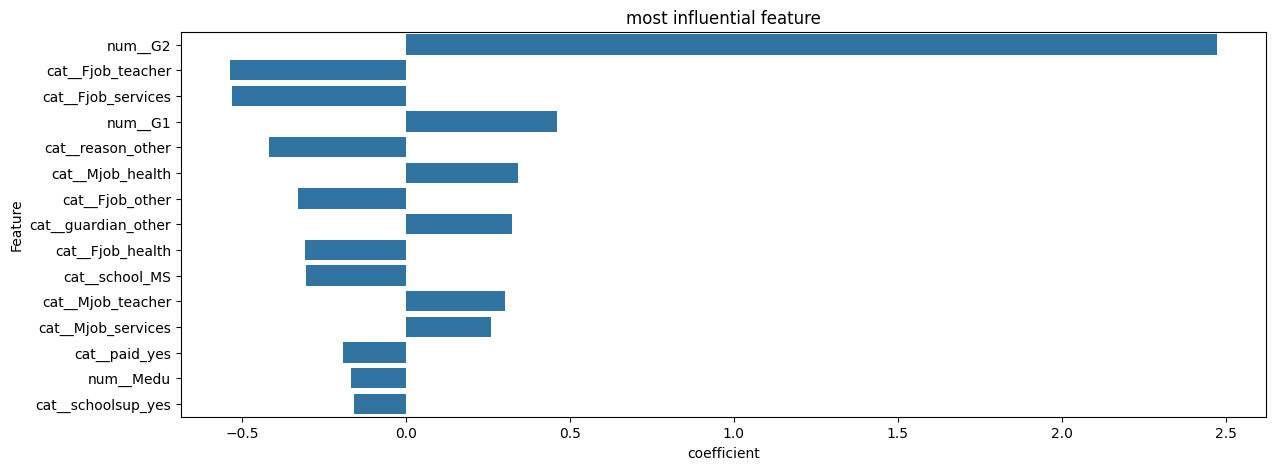

In [101]:
top_coef = coef_df.head(15) 

plt.figure(figsize=(14,5))
sns.barplot(data = top_coef, x='coefficient' , y='Feature') 
plt.title('most influential feature')
plt.xlabel('coefficient') 
plt.ylabel('Feature') 
plt.show()

# G2 is the dominant predictor of G3, followed by G1. The remaining displayed features have substantially smaller positive or negative coefficients.

# actual vs predicted 

<Figure size 1400x500 with 0 Axes>

<Figure size 1400x500 with 0 Axes>

<Figure size 1400x500 with 0 Axes>

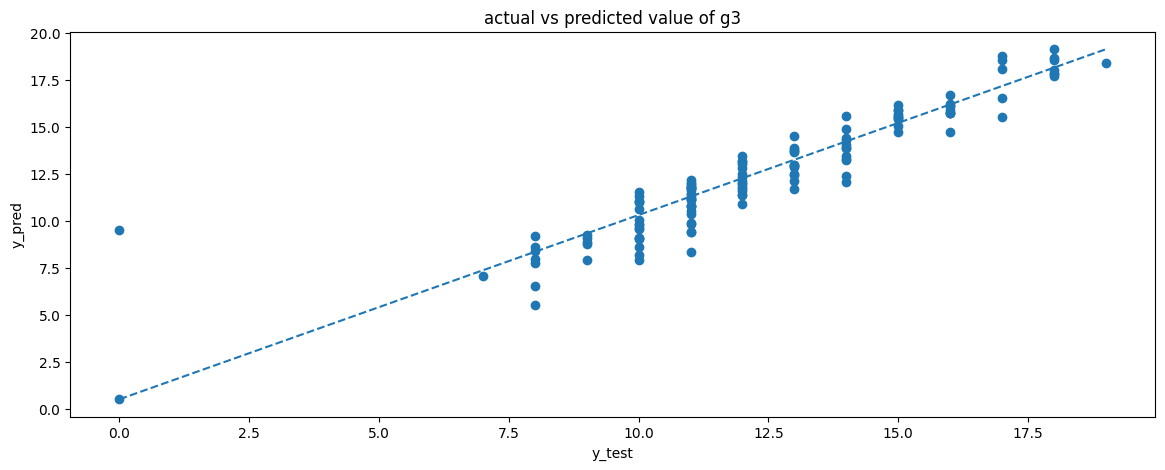

In [105]:
plt.figure(figsize=(14,5))
plt.scatter(y_test , y_pred)
plt.xlabel("y_test")
plt.ylabel("y_pred") 
plt.title("actual vs predicted value of g3")
# prediction line 
plt.plot([y_test.min() , y_test.max()],[y_pred.min(),y_pred.max()],linestyle='--')
plt.show()

# The actual-versus-predicted plot shows that most predicted G3 values are reasonably close to the ideal diagonal line, indicating that the Linear Regression model predicts the final exam scores relatively well on the test set. A few observations deviate substantially from the diagonal, indicating larger prediction errors for those students.

# residual plot

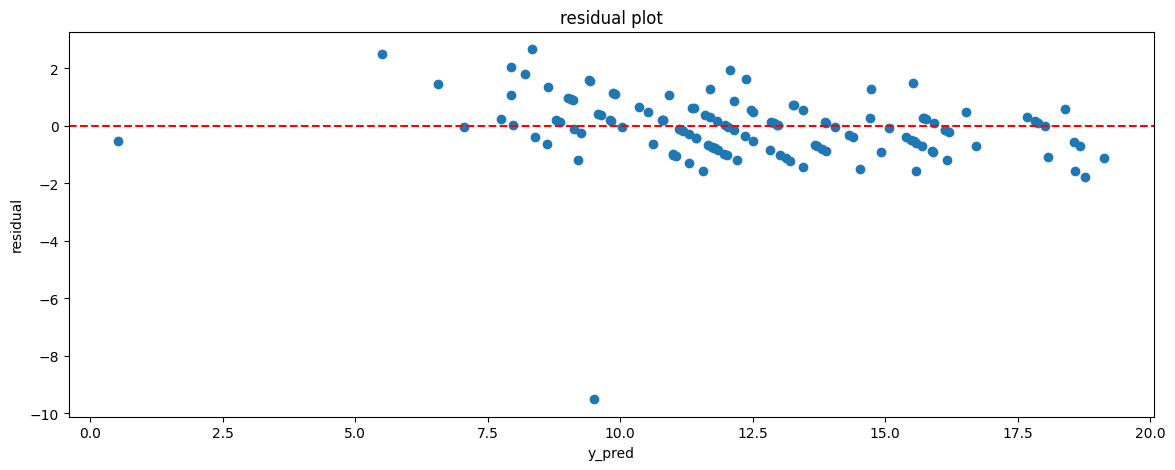

In [108]:
residual = y_test - y_pred 
plt.figure(figsize=(14,5))
plt.scatter(y_pred , residual )
plt.axhline(y=0, color='red' , linestyle = '--')
plt.title("residual plot")
plt.xlabel("y_pred") 
plt.ylabel("residual")
plt.show()

# The residuals are generally distributed around zero, indicating that the model captures much of the relationship between the features and G3. However, the residuals show a slight downward pattern and contain a significant negative outlier, suggesting that some systematic prediction error remains and the linear model does not explain all observations equally well